In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from econml.dml import CausalForestDML
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
data = pd.read_csv("D:\St Anns\AI\Supply Chain\Data\enhanced\walmart_final_with_trends.csv")
print(data.columns)
print(data.head())

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\SUDHIKSHA\AppData\Local\Temp\ipykernel_33256\2476576487.py:1: SyntaxWarning: invalid escape sequence '\S'
  data = pd.read_csv("D:\St Anns\AI\Supply Chain\Data\enhanced\walmart_final_with_trends.csv")


Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Type', 'Size', 'IsHoliday', 'YearWeek',
       'GoogleTrends_electronics', 'GoogleTrends_groceries',
       'GoogleTrends_clothing', 'GoogleTrends_toys', 'GoogleTrends_furniture',
       'GoogleTrends_sports equipment', 'GoogleTrends_beauty products',
       'GoogleTrends_home decor', 'GoogleTrends_electronics_lag1',
       'GoogleTrends_electronics_lag2', 'GoogleTrends_electronics_lag4',
       'GoogleTrends_groceries_lag1', 'GoogleTrends_groceries_lag2',
       'GoogleTrends_groceries_lag4', 'GoogleTrends_clothing_lag1',
       'GoogleTrends_clothing_lag2', 'GoogleTrends_clothing_lag4',
       'GoogleTrends_toys_lag1', 'GoogleTrends_toys_lag2',
       'GoogleTrends_toys_lag4', 'GoogleTrends_furniture_lag1',
       'GoogleTrends_furniture_lag2', 'GoogleTrends_furniture_lag4',
       'GoogleTrends_sports equi

In [3]:
data['IsHoliday'] = data['IsHoliday'].astype(int)

In [4]:
data['IsHoliday']

0         0
1         1
2         0
3         0
4         0
         ..
420280    0
420281    0
420282    0
420283    0
420284    0
Name: IsHoliday, Length: 420285, dtype: int32

In [5]:
data['Date'] = pd.to_datetime(data['Date'])

In [6]:
data = data.sort_values(['Store','Dept','Date'])

# Time features
data['Month'] = data['Date'].dt.month
data['Week'] = data['Date'].dt.isocalendar().week.astype(int)

# Lag features (important to control demand history)
data['Lag_1'] = data.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
data['Lag_4'] = data.groupby(['Store','Dept'])['Weekly_Sales'].shift(4)

data = data.dropna()

In [7]:
Y = data['Weekly_Sales'].values

In [8]:
T = data['IsHoliday'].values

In [9]:
X_cols = [
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Temperature',
    'Lag_1',
    'Lag_4',
    'Month',
    'Week',
    'Size'
]

X = data[X_cols].values

In [10]:
model_y = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model_t = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

In [11]:
cf = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=50,
    discrete_treatment=True,
    random_state=42
)

cf.fit(Y, T, X=X)

In [12]:
treatment_effect = cf.effect(X)
data['Holiday_Uplift'] = treatment_effect

In [13]:
data.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,GoogleTrends_beauty products_lag2,GoogleTrends_beauty products_lag4,GoogleTrends_home decor_lag1,GoogleTrends_home decor_lag2,GoogleTrends_home decor_lag4,Month,Week,Lag_1,Lag_4,Holiday_Uplift
4,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,...,89.0,100.0,92.0,96.0,100.0,3,9,19403.54,24924.50,-1.145554e+06
5,1,1,2010-03-12,21043.39,57.79,2.667,0.0,0.0,0.0,0.0,...,100.0,89.0,97.0,92.0,93.0,3,10,21827.90,46039.49,-8.602890e+05
6,1,1,2010-03-19,22136.64,54.58,2.720,0.0,0.0,0.0,0.0,...,96.0,89.0,83.0,97.0,96.0,3,11,21043.39,41595.55,-1.710829e+06
7,1,1,2010-03-26,26229.21,51.45,2.732,0.0,0.0,0.0,0.0,...,92.0,100.0,91.0,83.0,92.0,3,12,22136.64,19403.54,6.937250e+05
8,1,1,2010-04-02,57258.43,62.27,2.719,0.0,0.0,0.0,0.0,...,99.0,96.0,82.0,91.0,97.0,4,13,26229.21,21827.90,1.553133e+06


In [24]:
uplift_data_total = data[['Store','Dept','Fuel_Price',
    'CPI',
    'Unemployment',
    'Temperature',
    'Lag_1',
    'Lag_4',
    'Month',
    'Week',
    'Size', 'Weekly_Sales', 'Holiday_Uplift']]
uplift_data_total.head()

,Store,Dept,Fuel_Price,CPI,Unemployment,Temperature,Lag_1,Lag_4,Month,Week,Size,Weekly_Sales,Holiday_Uplift
4,1,1,2.625,211.350143,8.106,46.50,19403.54,24924.50,3,9,151315,21827.90,-1.145554e+06
5,1,1,2.667,211.380643,8.106,57.79,21827.90,46039.49,3,10,151315,21043.39,-8.602890e+05
6,1,1,2.720,211.215635,8.106,54.58,21043.39,41595.55,3,11,151315,22136.64,-1.710829e+06
7,1,1,2.732,211.018042,8.106,51.45,22136.64,19403.54,3,12,151315,26229.21,6.937250e+05
8,1,1,2.719,210.820450,7.808,62.27,26229.21,21827.90,4,13,151315,57258.43,1.553133e+06


In [25]:
uplift_data_total.to_csv('uplift_data.csv')

In [19]:
ate = np.mean(treatment_effect)
print("Average Holiday Effect:", ate)

Average Holiday Effect: 359935.15894710703


In [20]:
lb, ub = cf.effect_interval(X)
print("ATE Confidence Interval:", np.mean(lb), np.mean(ub))

ATE Confidence Interval: -1332965.8807418777 2052836.1986360908


In [21]:
store_dept_uplift = (
    data.groupby(['Store', 'Dept'])['Holiday_Uplift']
    .mean()
    .sort_values(ascending=False)
)

print(store_dept_uplift)

Store  Dept
27     92      1.464798e+07
2      95      1.201276e+07
20     95      1.110478e+07
10     72      1.110062e+07
14     95      1.104559e+07
                   ...     
4      13     -1.059414e+06
       94     -1.114141e+06
11     40     -1.173822e+06
4      38     -1.270637e+06
       40     -1.470584e+06
Name: Holiday_Uplift, Length: 3211, dtype: float64


In [23]:
store_dept_uplift_data = pd.DataFrame(store_dept_uplift)
store_dept_uplift_data

Holiday_Uplift
Store Dept                
27    92      1.464798e+07
2     95      1.201276e+07
20    95      1.110478e+07
10    72      1.110062e+07
14    95      1.104559e+07
...                    ...
4     13     -1.059414e+06
      94     -1.114141e+06
11    40     -1.173822e+06
4     38     -1.270637e+06
      40     -1.470584e+06

[3211 rows x 1 columns]

In [29]:
store_dept_uplift_data = store_dept_uplift_data.ffill()
store_dept_uplift_data.to_csv('store_dept_uplift_data.csv')

In [31]:
store_uplift = (
    data.groupby('Store')['Holiday_Uplift']
    .mean()
    .sort_values(ascending=False)
)

print(store_uplift.head())

Store
14    1.279441e+06
27    1.183975e+06
10    9.296597e+05
24    8.992563e+05
19    7.558034e+05
Name: Holiday_Uplift, dtype: float64


In [32]:
store_uplift_data = pd.DataFrame(store_uplift)
store_uplift_data.to_csv('store_uplift_data.csv')

In [33]:
dept_uplift = (
    data.groupby('Dept')['Holiday_Uplift']
    .mean()
    .sort_values(ascending=False)
)

print(dept_uplift.head())

Dept
92    2.702266e+06
95    2.404688e+06
72    1.370060e+06
38    1.096966e+06
1     8.734168e+05
Name: Holiday_Uplift, dtype: float64


In [34]:
dept_uplift_data = pd.DataFrame(dept_uplift)
dept_uplift_data.to_csv('dept_uplift_data.csv')

In [35]:
importance = cf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X_cols,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

        Feature  Importance
5         Lag_4    0.371475
4         Lag_1    0.193158
0    Fuel_Price    0.128464
1           CPI    0.101614
7          Week    0.052369
2  Unemployment    0.047373
8          Size    0.046747
3   Temperature    0.046125
6         Month    0.012674


In [36]:
importance_df.to_csv('feature_importance.csv')

In [44]:
import shap

In [51]:
train_sales = pd.read_csv('D:/St Anns/AI/Supply Chain/Data/Raw/walmart/train.csv')
test_sales = pd.read_csv('D:/St Anns/AI/Supply Chain/Data/Raw/walmart/test.csv')
features = pd.read_csv('D:/St Anns/AI/Supply Chain/Data/Raw/walmart/features.csv')
stores = pd.read_csv('D:/St Anns/AI/Supply Chain/Data/Raw/walmart/stores.csv')

In [56]:
train_sales['Date'] = pd.to_datetime(train_sales['Date'])
test_sales['Date'] = pd.to_datetime(train_sales['Date'])
features['Date'] = pd.to_datetime(features['Date'])
sales = pd.concat([train_sales, test_sales], ignore_index=True)

In [57]:
data = sales.merge(features, on=['Store', 'Date'], how='left')
data = data.merge(stores, on='Store', how='left')

In [63]:
data['IsHoliday'] = data['IsHoliday_x']
data = data.drop(['IsHoliday_x','IsHoliday_y'], axis = 1)

In [64]:
data = data.sort_values(['Store', 'Dept', 'Date'])
data['Lag_1'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
data['Lag_4'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(4)
data['Rolling_Mean_4'] = data.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).rolling(4).mean()

In [65]:
data['IsHoliday'] = data['IsHoliday'].astype(int)

In [66]:
data['Fuel_Holiday'] = data['Fuel_Price'] * data['IsHoliday']
data['CPI_Holiday'] = data['CPI'] * data['IsHoliday']

In [67]:
data = data.dropna()

In [93]:
target = 'Weekly_Sales'

features_cols = [
    'IsHoliday',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Temperature',
    'Store',
    'Dept',
    'Type',
    'Size',
    'Lag_1',
    'Lag_4',
    'Rolling_Mean_4',
    'Fuel_Holiday',
    'CPI_Holiday'
]

X = pd.get_dummies(data[features_cols], drop_first=True)
y = data[target]

In [94]:
X.dtypes

IsHoliday           int32
Fuel_Price        float64
CPI               float64
Unemployment      float64
Temperature       float64
Store               int64
Dept                int64
Size                int64
Lag_1             float64
Lag_4             float64
Rolling_Mean_4    float64
Fuel_Holiday      float64
CPI_Holiday       float64
Type_B               bool
Type_C               bool
dtype: object

In [106]:
X['Type_B'] = X['Type_B'].astype('int')
X['Type_C'] = X['Type_C'].astype('int')

In [107]:
X = X.apply(pd.to_numeric, errors = 'coerce')

In [108]:
X.head()

,IsHoliday,Fuel_Price,CPI,Unemployment,Temperature,Store,Dept,Size,Lag_1,Lag_4,Rolling_Mean_4,Fuel_Holiday,CPI_Holiday,Type_B,Type_C
92,0,3.297,217.998085,7.866,59.11,1,1,151315,39886.06,23077.55,29473.8275,0.000,0.000000,0,0
93,0,3.308,218.220509,7.866,62.25,1,1,151315,18689.54,23351.80,28376.8250,0.000,0.000000,0,0
94,1,3.236,218.467621,7.866,60.14,1,1,151315,19050.66,31579.90,27301.5400,3.236,218.467621,0,0
95,0,3.172,218.714733,7.866,48.91,1,1,151315,20911.25,39886.06,24634.3775,0.000,0.000000,0,0
96,0,3.158,218.961846,7.866,43.93,1,1,151315,25293.49,18689.54,20986.2350,0.000,0.000000,0,0


In [109]:
X = X.fillna(0)

In [110]:
split_date = data['Date'].quantile(0.8)

X_train = X[data['Date'] <= split_date]
X_test  = X[data['Date'] > split_date]

y_train = y[data['Date'] <= split_date]
y_test  = y[data['Date'] > split_date]

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

In [111]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("MAPE:", mean_absolute_percentage_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 2290.275729257515
MAPE: 151797335547758.03
R2: 0.9059667623681479


In [112]:
X_holiday = X_test.copy()
X_noholiday = X_test.copy()

X_holiday['IsHoliday'] = 1
X_noholiday['IsHoliday'] = 0

holiday_pred = model.predict(X_holiday)
noholiday_pred = model.predict(X_noholiday)

uplift = holiday_pred - noholiday_pred

print("Average Holiday Uplift:", np.mean(uplift))

Average Holiday Uplift: 165.96814


In [114]:
X = X.apply(pd.to_numeric, errors='coerce')

In [117]:
print(X.dtypes)

IsHoliday           int32
Fuel_Price        float64
CPI               float64
Unemployment      float64
Temperature       float64
Store               int64
Dept                int64
Size                int64
Lag_1             float64
Lag_4             float64
Rolling_Mean_4    float64
Fuel_Holiday      float64
CPI_Holiday       float64
Type_B              int32
Type_C              int32
dtype: object


In [91]:
print(X.head())

    IsHoliday  Fuel_Price         CPI  Unemployment  Temperature  Store  Dept  \
92          0       3.297  217.998085         7.866        59.11      1     1   
93          0       3.308  218.220509         7.866        62.25      1     1   
94          1       3.236  218.467621         7.866        60.14      1     1   
95          0       3.172  218.714733         7.866        48.91      1     1   
96          0       3.158  218.961846         7.866        43.93      1     1   

      Size     Lag_1     Lag_4  Rolling_Mean_4  Fuel_Holiday  CPI_Holiday  \
92  151315  39886.06  23077.55      29473.8275         0.000     0.000000   
93  151315  18689.54  23351.80      28376.8250         0.000     0.000000   
94  151315  19050.66  31579.90      27301.5400         3.236   218.467621   
95  151315  20911.25  39886.06      24634.3775         0.000     0.000000   
96  151315  25293.49  18689.54      20986.2350         0.000     0.000000   

    Type_B  Type_C  
92   False   False  
93   Fal

PermutationExplainer explainer: 12981it [37:04,  5.82it/s]                           
C:\Users\SUDHIKSHA\AppData\Local\Temp\ipykernel_19956\348945282.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


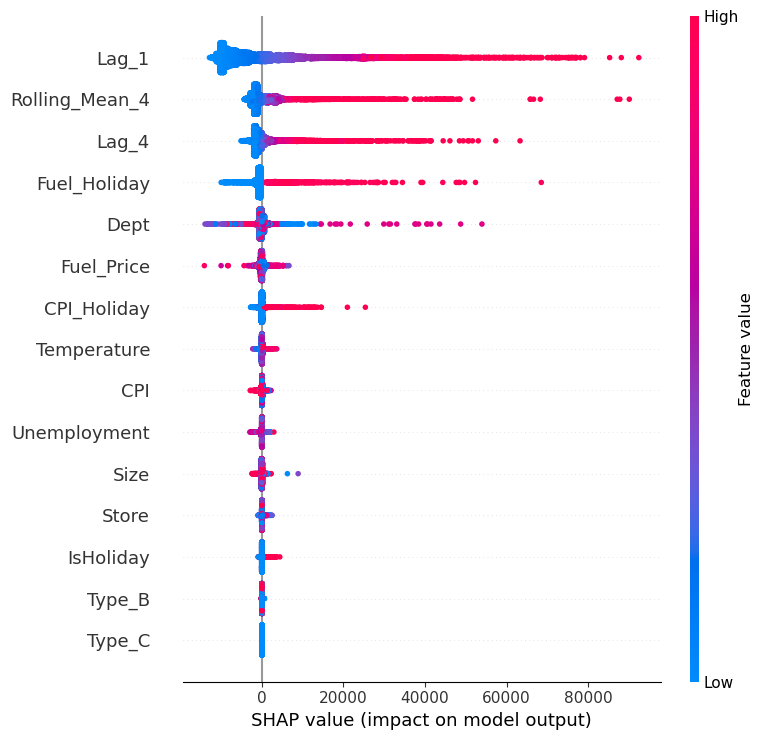

In [120]:
explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [121]:
shap_df = pd.DataFrame(shap_values.values, columns = X.columns)
shap_df_long = pd.concat([shap_df, X.reset_index(drop=True)], axis=1)

In [122]:
shap_df_long.head()

,IsHoliday,Fuel_Price,CPI,Unemployment,Temperature,Store,Dept,Size,Lag_1,Lag_4,...,Store,Dept,Size,Lag_1,Lag_4,Rolling_Mean_4,Fuel_Holiday,CPI_Holiday,Type_B,Type_C
0,46.166735,527.904176,-146.527031,-42.666455,183.994691,90.698211,251.267470,-62.318814,1616.312816,90.349535,...,1,1,151315,39886.06,23077.55,29473.8275,0.000,0.000000,0,0
1,51.564054,-670.722891,-193.741176,-22.878887,201.716155,40.953811,-32.050065,-60.402913,1700.279806,-140.245655,...,1,1,151315,18689.54,23351.80,28376.8250,0.000,0.000000,0,0
2,55.618821,519.931605,-128.371885,-13.360993,66.877134,58.108695,182.302779,-76.136276,2049.288451,-38.980898,...,1,1,151315,19050.66,31579.90,27301.5400,3.236,218.467621,0,0
3,42.804843,542.051049,-128.759574,-28.382323,52.761907,66.073334,257.862368,-66.753912,1568.746403,-57.222580,...,1,1,151315,20911.25,39886.06,24634.3775,0.000,0.000000,0,0
4,-268.957317,38.138361,-262.726270,-11.582130,246.536261,399.222844,-284.547334,-160.452780,1610.424474,-550.489029,...,1,1,151315,25293.49,18689.54,20986.2350,0.000,0.000000,0,0


In [123]:
shap_df_long.to_csv('shap_data.csv', index = False)

In [ ]:
shap_values = pd.read_csv('shap_data.csv')